## 1. Verify GPU

In [1]:
import subprocess

result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

if result.returncode != 0:
    raise RuntimeError(
        "No GPU detected. Go to Runtime â†’ Change runtime type â†’ T4 GPU and reconnect."
    )

Tue Apr 28 09:59:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Mount Google Drive & Set Project Directory

Drive is the single source of truth â€” dataset will be downloaded here and all training outputs (weights, plots) are written back here automatically.

In [21]:
from google.colab import drive
drive.mount('/content/drive')

import os

# â”€â”€ Update this if your Drive path is different â”€â”€
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/Construction-Safety-Monitor'

if not os.path.exists(DRIVE_PROJECT_DIR):
    raise FileNotFoundError(
        f"Project folder not found on Drive: {DRIVE_PROJECT_DIR}\n"
        "Make sure the src/ folder is uploaded to Drive and DRIVE_PROJECT_DIR is correct."
    )

os.chdir(DRIVE_PROJECT_DIR)
print(f"Working directory: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/Construction-Safety-Monitor


## 3. Install Dependencies

In [9]:
!pip install ultralytics roboflow pyyaml --quiet

import ultralytics, roboflow, yaml
print(f"ultralytics : {ultralytics.__version__}")
print(f"roboflow    : {roboflow.__version__}")
print(f"pyyaml      : {yaml.__version__}")

ultralytics : 8.4.42
roboflow    : 1.3.6
pyyaml      : 6.0.3


## 4. Download Dataset from Roboflow

Downloads to  on Drive. Skipped if the dataset is already there.
Also fixes a known bad label (segmentation polygon) in the train split.


In [22]:
from pathlib import Path
import shutil
from roboflow import Roboflow

DATA_YAML = Path('data/raw/data.yaml')

if DATA_YAML.exists():
    print("Dataset already present â€” skipping download.")
else:
    rf = Roboflow(api_key="VAK7OsUK4qpq5Xp9yMoS")  # keep this private
    project = rf.workspace("zukoos-workspace").project("construction-ppe-fwz4e")
    version = project.version(1)
    version.download("yolov8")  # Roboflow downloads to ./{project}-{version}/ in cwd

    # Find the downloaded folder (Roboflow controls the name)
    found = [f for f in Path('.').rglob('data.yaml') if 'data/raw' not in str(f)]
    if not found:
        raise FileNotFoundError("data.yaml not found after download.")

    download_root = found[0].parent
    print(f"Downloaded to: {download_root}")

    # Move into data/raw/
    Path('data/raw').mkdir(parents=True, exist_ok=True)
    for item in download_root.iterdir():
        shutil.move(str(item), 'data/raw/')
    download_root.rmdir()
    print("Dataset ready at: data/raw/")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to construction-ppe-1 in yolov8:: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 1005/1005 [00:08<00:00, 119.34it/s]


Downloaded to: construction-ppe-1
Dataset ready at: data/raw/


## 5. Validate Dataset

Runs `data_preparation.py` â€” training is blocked if validation fails.

In [30]:
import subprocess, sys

result = subprocess.run(
    [sys.executable, "src/data_preparation.py", "--data", "data/raw/data.yaml"],
    capture_output=True,
    text=True
)

print(result.stdout)
if result.stderr:
    print(result.stderr)

# Validation is advisory only - issues here do not block training
if result.returncode != 0:
    print("[WARNING] Validation reported issues - proceeding to training anyway.")
else:
    print("Dataset validation PASSED.")



Loaded: /content/drive/MyDrive/Construction-Safety-Monitor/data/raw/data.yaml
Classes (7): ['belt', 'boot', 'gloves', 'goggles', 'helmat', 'person', 'vest']

  DATASET VALIDATION SUMMARY

Split        Images   Labels
------------------------------
train           350      350
val             100      100
test             50       50

Class             train       val      test     Total
----------------------------------------------------
belt                 19         5         3        27
boot                212        63        21       296
gloves              307        95        48       450
goggles              86        31        16       133
helmat              309        97        46       452
person              342        85        52       479
vest                243        52        27       322
----------------------------------------------------
TOTAL                                            2159

  Status: PASSED -- dataset looks clean.


Dataset validation PASSED.


## 6. Train

  
All outputs are written directly to `runs/train/ppe_yolov8s/` on Drive.

In [31]:
!python src/train.py


  PPE DETECTION — YOLOv8s TRAINING
  data     : /content/drive/MyDrive/Construction-Safety-Monitor/data/raw/data.yaml
  weights  : yolov8s.pt
  epochs   : 25
  batch    : 16
  imgsz    : 640
  run name : ppe_yolov8s

Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Construction-Safety-Monitor/data/raw/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, li

## 7. Review Training Results

Displays training curves saved by Ultralytics.  
`best.pt` is already on Drive at `runs/train/ppe_yolov8s/weights/best.pt`.


--- results.png ---


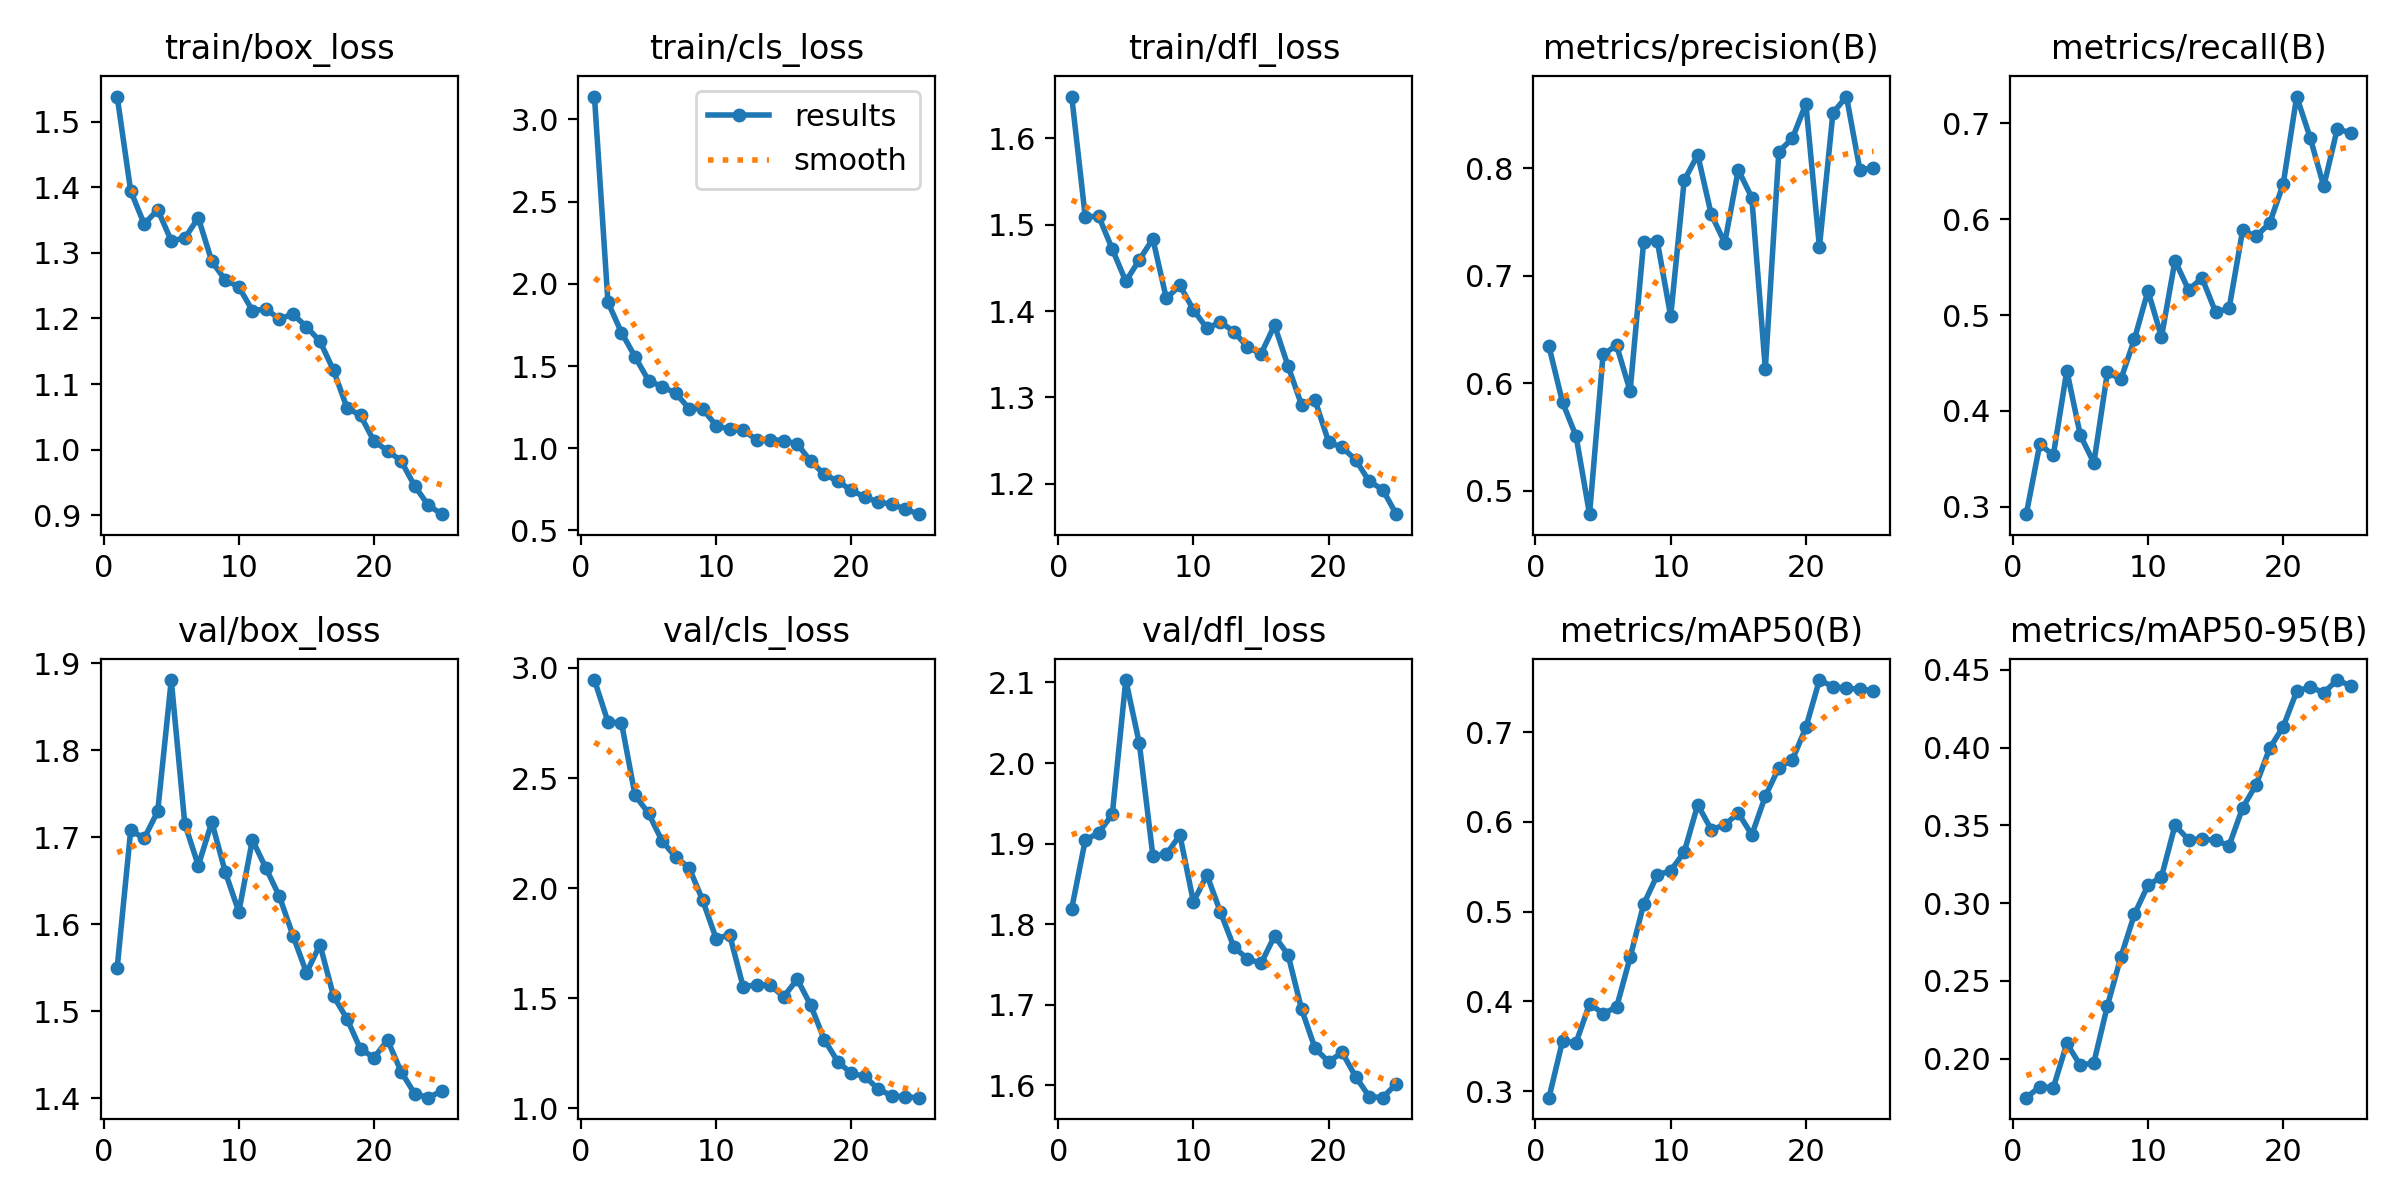


--- confusion_matrix.png ---


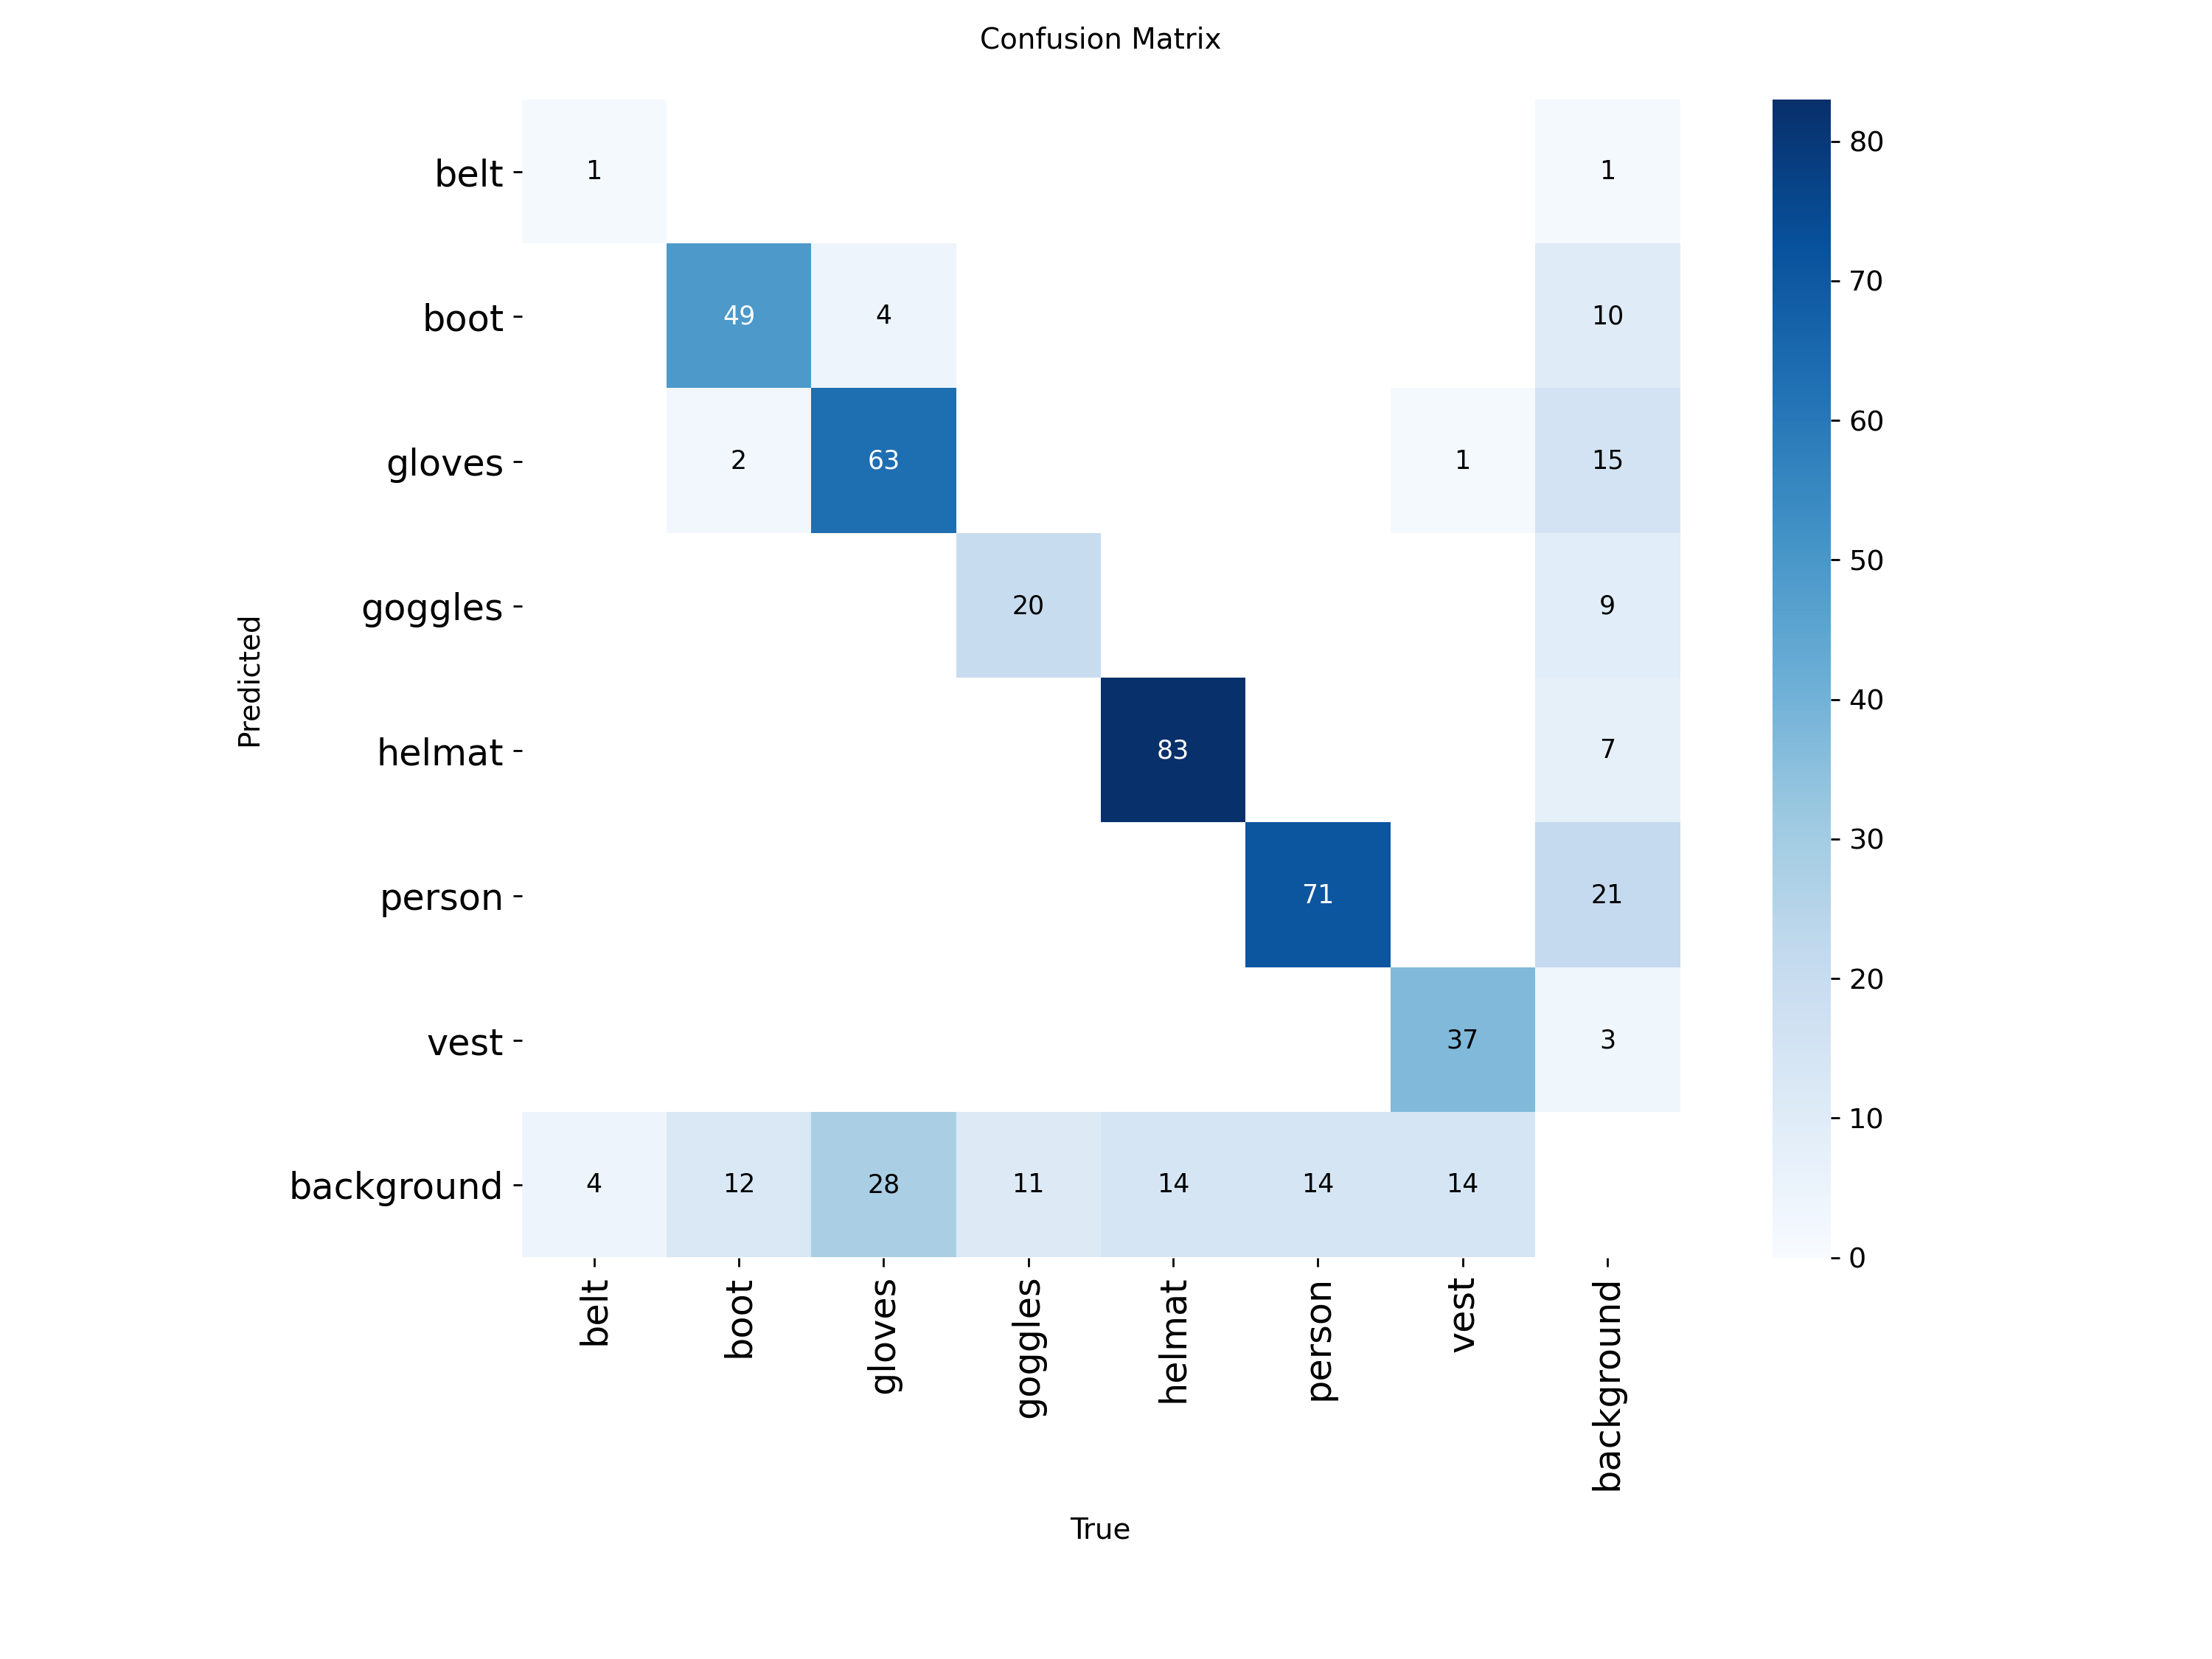

[skip] PR_curve.png not found
[skip] F1_curve.png not found

Best weights â†’ FOUND : runs/detect/ppe_yolov8s/weights/best.pt


In [33]:
from pathlib import Path
from IPython.display import Image, display

run_dir = Path('runs/detect/ppe_yolov8s')

if not run_dir.exists():
    print(f"[WARNING] Run directory not found: {run_dir}")
else:
    for plot in ['results.png', 'confusion_matrix.png', 'PR_curve.png', 'F1_curve.png']:
        p = run_dir / plot
        if p.exists():
            print(f"\n--- {plot} ---")
            display(Image(str(p), width=800))
        else:
            print(f"[skip] {plot} not found")

    best_pt = run_dir / 'weights' / 'best.pt'
    print(f"\nBest weights â†’ {'FOUND' if best_pt.exists() else 'NOT FOUND'} : {best_pt}")

## 8. Prediction vs Ground Truth Check

Runs the trained model on a sample of val images and draws predicted boxes (green) vs actual labels (red) side by side.

images-193-_jpeg_jpg.rf.46c95b4bfad7db1fbfa6bc000013c265.jpg


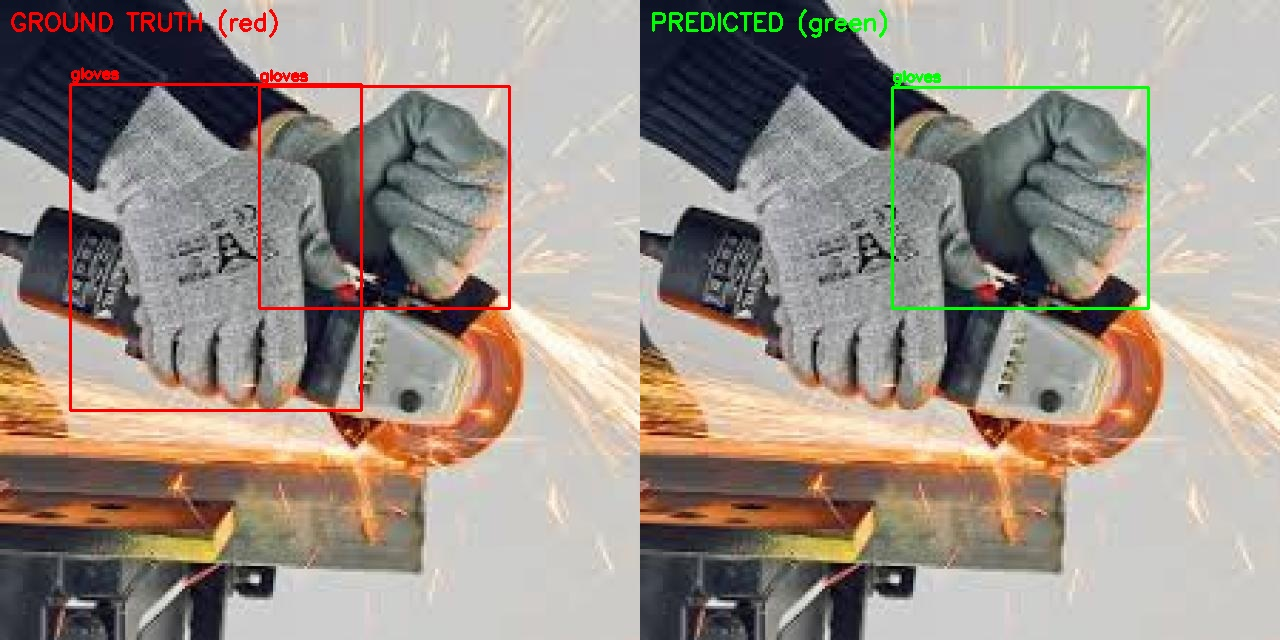

image82_jpg.rf.9717a65734017f8c2779a9909f149760.jpg


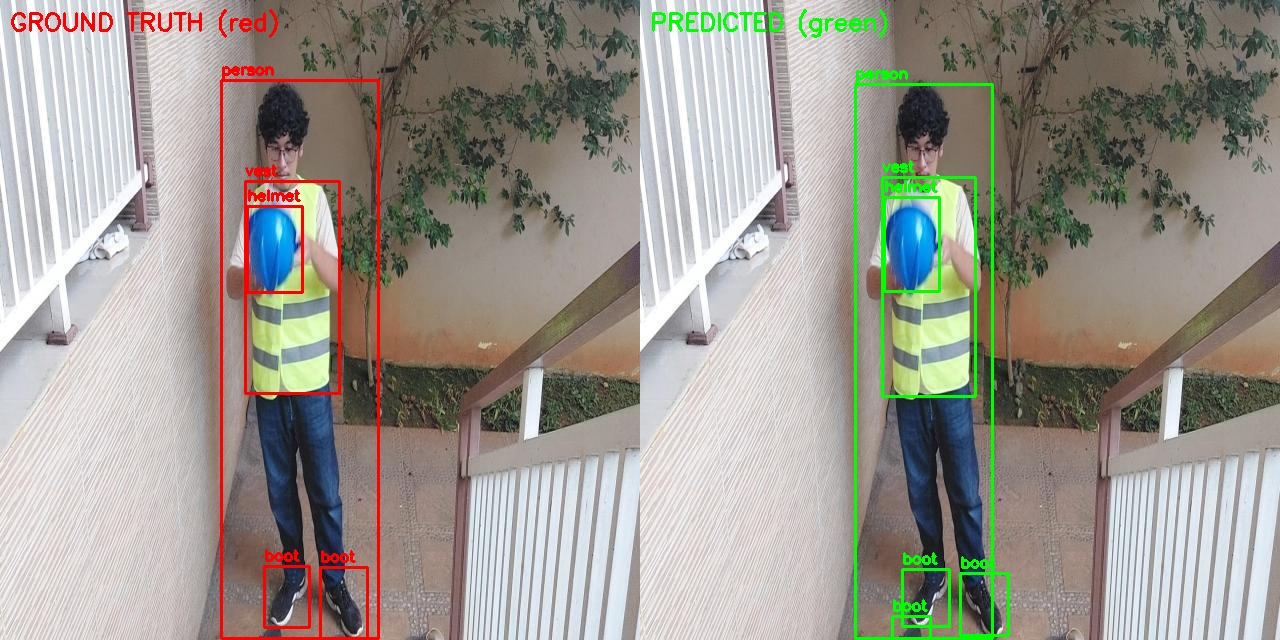

XSHF4911_JPEG_jpg.rf.1db64fbf4ffa20dbf3be9d262f0e38c6.jpg


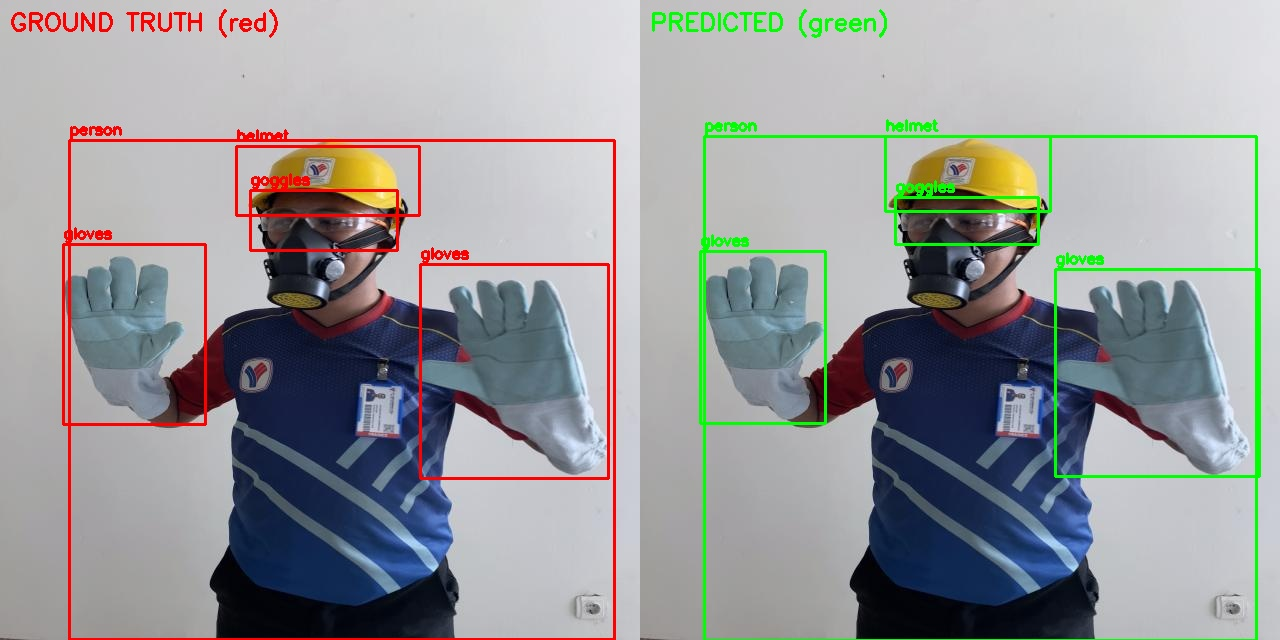

XEZP4987_JPEG_jpg.rf.0f0253dfc883712c3f650852b17c3e41.jpg


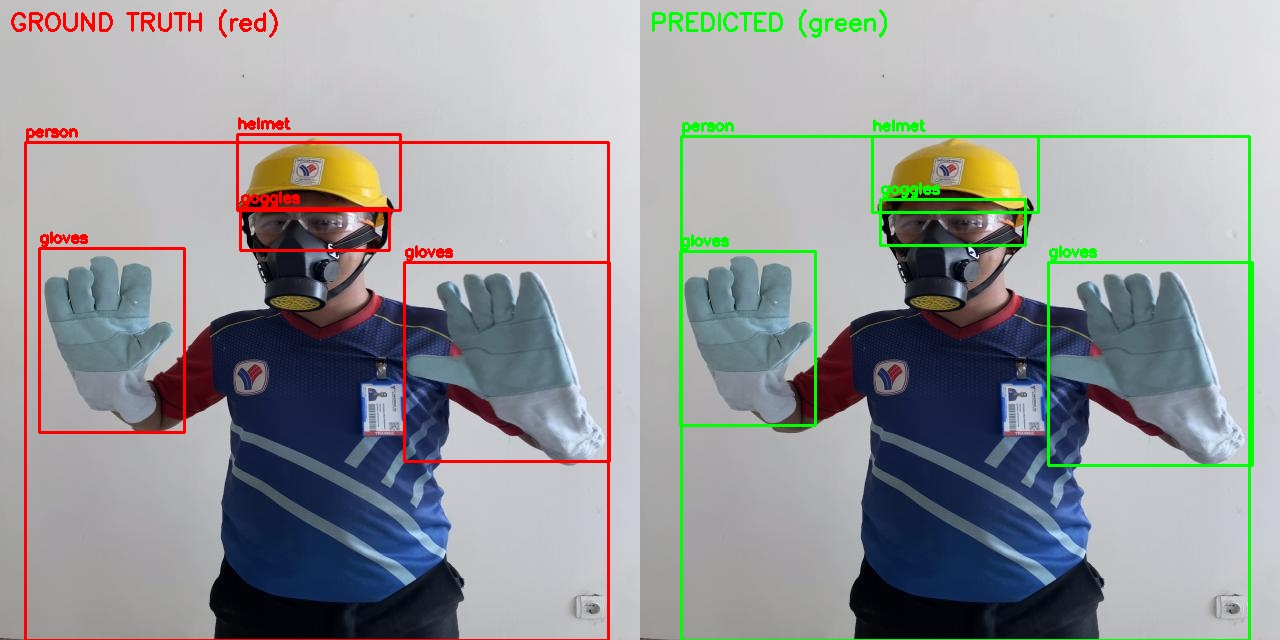

image36_jpg.rf.3adcdd6317f6f28519298ab8a216b69e.jpg


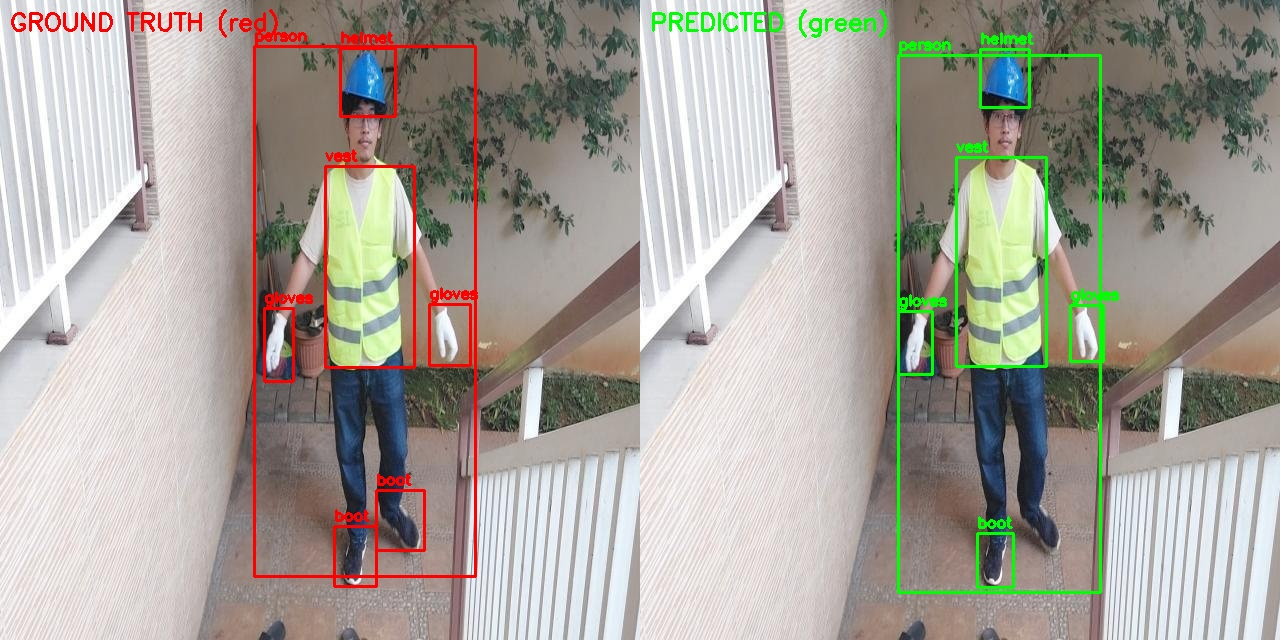

In [36]:
import cv2
import random
import numpy as np
from pathlib import Path
from ultralytics import YOLO
from IPython.display import Image as IPImage, display

WEIGHTS    = Path("runs/detect/ppe_yolov8s/weights/best.pt")
VAL_IMAGES = Path("data/raw/valid/images")
VAL_LABELS = Path("data/raw/valid/labels")
CLASS_NAMES = ["belt", "boot", "gloves", "goggles", "helmet", "person", "vest"]
CONF_THRESH = 0.35
NUM_SAMPLES = 5       # how many images to check

if not WEIGHTS.exists():
    raise FileNotFoundError(f"Weights not found: {WEIGHTS}")

model = YOLO(str(WEIGHTS))

images = sorted(VAL_IMAGES.glob("*.jpg")) + sorted(VAL_IMAGES.glob("*.png"))
samples = random.sample(images, min(NUM_SAMPLES, len(images)))

def draw_boxes(img, boxes_xywhn, color, thickness=2):
    """Draw normalised cx,cy,w,h boxes on img."""
    h, w = img.shape[:2]
    for cls, cx, cy, bw, bh in boxes_xywhn:
        x1 = int((cx - bw / 2) * w)
        y1 = int((cy - bh / 2) * h)
        x2 = int((cx + bw / 2) * w)
        y2 = int((cy + bh / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
        label = CLASS_NAMES[int(cls)] if int(cls) < len(CLASS_NAMES) else str(int(cls))
        cv2.putText(img, label, (x1, max(y1 - 6, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, thickness)

for img_path in samples:
    img_gt   = cv2.imread(str(img_path))
    img_pred = img_gt.copy()

    # --- Ground truth (RED) ---
    lbl_path = VAL_LABELS / (img_path.stem + ".txt")
    gt_boxes = []
    if lbl_path.exists():
        for line in lbl_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) == 5:
                gt_boxes.append([float(p) for p in parts])
    draw_boxes(img_gt, gt_boxes, color=(0, 0, 255))   # red

    # --- Prediction (GREEN) ---
    results = model.predict(str(img_path), conf=CONF_THRESH, verbose=False)[0]
    pred_boxes = []
    for box in results.boxes:
        cls = int(box.cls[0])
        cx, cy, bw, bh = box.xywhn[0].tolist()
        pred_boxes.append([cls, cx, cy, bw, bh])
    draw_boxes(img_pred, pred_boxes, color=(0, 255, 0))  # green

    # --- Side-by-side display ---
    combined = np.concatenate([img_gt, img_pred], axis=1)
    h_combined = combined.shape[0]
    cv2.putText(combined, "GROUND TRUTH (red)",  (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    cv2.putText(combined, "PREDICTED (green)", (img_gt.shape[1] + 10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    out_path = f"/tmp/check_{img_path.stem}.jpg"
    cv2.imwrite(out_path, combined)
    print(f"{img_path.name}")
    display(IPImage(out_path, width=1000))
